In [1]:
import scarf

scarf.configure_output(level="ERROR", progress=True)

counts = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5",
    destination="scarf_datasets",
)[0]

store = counts.with_name("data.zarr")
reader = scarf.CrH5Reader(str(counts))
scarf.CrToZarr(
    reader,
    zarr_loc=str(store),
).dump()

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

Writing counts: 3 / 3 complete

In [2]:
ds = scarf.DataStore(
    str(store),
    nthreads=4,
)

Computing RNA initialization statistics: 3 / 3 complete

In [3]:
artifacts = ds.pipeline.run()

Computing RNA feature statistics: 6 / 6 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

...

Computing RNA initialization statistics: 3 / 3 complete

Normalizing with feature subset: 3 / 3 complete

(RNA) Writing aligned data to normed__I__hvgs_doublet: 3 / 3 complete

Mapping cells from _doublet_sim_RNA: 1 / 1 complete

Finding markers: 1 / 1 complete

In [4]:
sorted(artifacts)

['ann_index',
 'cell_cycle',
 'cell_selection',
 'connectivity_map',
 'doublets',
 'embedding_initialization',
 'highly_variable_features',
 'leiden_0.5',
 'leiden_0.75',
 'leiden_1.0',
 'leiden_1.25',
 'markers',
 'neighbors',
 'normalized',
 'paris',
 'pca',
 'selected_clusters',
 'umap']

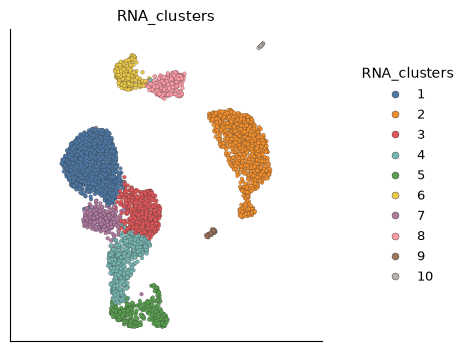

In [5]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_clusters",
)

Aggregating marker values per group: 3 / 3 complete

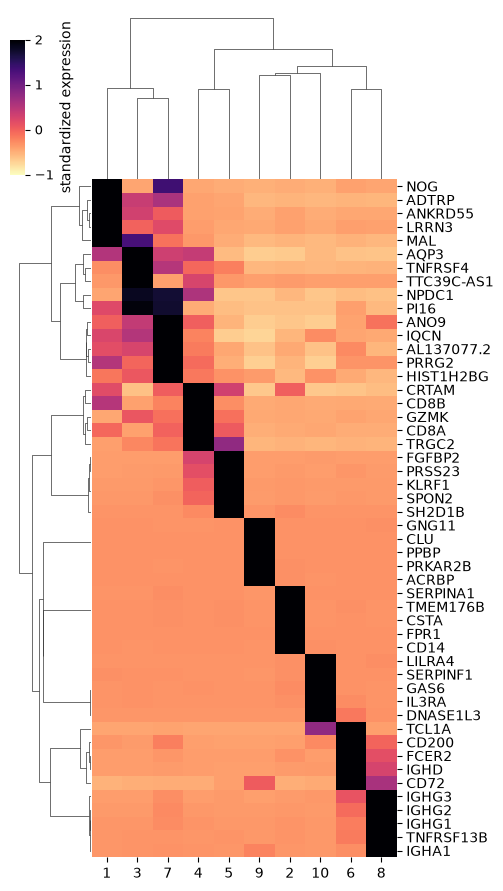

In [6]:
ds.plots.marker_heatmap(
    group_key="RNA_clusters",
    topn=5,
    figsize=(5, 9),
)